In [ ]:
# IMPORT LIBRARIES

!pip install torch torchvision matplotlib seaborn scikit-learn

import torch
import torch.nn as nn    #used for layers, AF
import torch.optim as optim    #used to udate model weights during training
import torchvision     #provides datasets
import torchvision.transforms as transforms   #used to modify resize
import torchvision.models as models     #gives ready models

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# DEVICE CONFIGURATION

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# LOAD CIFAR-10 DATASET

transform = transforms.Compose([     #combines multiple transformation into single pipeline
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)   #folder to store dataset,apply preprocessing

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)     #loads data into batches
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = trainset.classes
print("Classes:", classes)

100%|██████████| 170M/170M [00:04<00:00, 40.3MB/s]


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# ACTIVATION FUNCTIONS    defines AF and stores themfor comparison

class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(nn.functional.softplus(x))

activations = {
    "ReLU": nn.ReLU(),     # baseline
    "GELU": nn.GELU(),     # smooth
    "Swish": Swish(),      # smooth
    "Mish": Mish()         # smooth
}

In [ ]:
# RESNET MODEL WITH CUSTOM ACTIVATION


def replace_activation(model, activation):
    for name, module in model.named_children():   # access the layers inside a model one by one with their names
        if isinstance(module, nn.ReLU):   # checks type of object
            setattr(model, name, activation)   # sets/changes attribute of object
        else:
            replace_activation(module, activation)

def get_resnet(activation):
    model = models.resnet18(weights=None)

    # for CIFAR-10 (32x32 images)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()   # removes poling layers identity does nthg passes input as it is

    model.fc = nn.Linear(model.fc.in_features, 10)   # change o/p layer

    replace_activation(model, activation)

    return model.to(device)

In [ ]:
# TRAINING FUNCTION

def train_model(model, epochs=5):
    criterion = nn.CrossEntropyLoss()    # measures how wrong predictions are used for clasification
    optimizer = optim.Adam(model.parameters(), lr=0.001)    # Updates model weights to reduce loss

    train_acc_list = []    # Store accuracy for each epoch
    test_acc_list = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        # TRAINING
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = 100 * correct / total
        avg_loss = running_loss / len(trainloader)     # Mean loss per batch

        # TESTING
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        test_acc = 100 * correct / total     # Performance on unseen data

        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.3f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    return train_acc_list, test_acc_list

In [ ]:
# EVALUATION FUNCTIONS

def get_predictions(model):    #generates predictions of the model on test data
    y_true, y_pred = [], []

    model.eval()
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)    #model predict probablities
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("Accuracy:", accuracy_score(y_true, y_pred))

In [ ]:
# RESNET EXPERIMENT

resnet_results = {}
resnet_models = {}

for name, act in activations.items():
    print(f"\nTraining ResNet with {name}")

    model = get_resnet(act)
    train_acc, test_acc = train_model(model)

    resnet_results[name] = test_acc   # store test accuracy
    resnet_models[name] = model


Training ResNet with ReLU
Epoch [1/5] | Loss: 1.209 | Train Acc: 56.21% | Test Acc: 69.88%
Epoch [2/5] | Loss: 0.711 | Train Acc: 75.10% | Test Acc: 75.28%
Epoch [3/5] | Loss: 0.531 | Train Acc: 81.51% | Test Acc: 75.27%
Epoch [4/5] | Loss: 0.412 | Train Acc: 85.62% | Test Acc: 81.97%
Epoch [5/5] | Loss: 0.304 | Train Acc: 89.41% | Test Acc: 81.72%

Training ResNet with GELU
Epoch [1/5] | Loss: 1.185 | Train Acc: 56.88% | Test Acc: 69.12%
Epoch [2/5] | Loss: 0.685 | Train Acc: 75.92% | Test Acc: 79.41%
Epoch [3/5] | Loss: 0.498 | Train Acc: 82.76% | Test Acc: 80.26%
Epoch [4/5] | Loss: 0.366 | Train Acc: 87.35% | Test Acc: 81.32%
Epoch [5/5] | Loss: 0.263 | Train Acc: 90.75% | Test Acc: 83.22%

Training ResNet with Swish
Epoch [1/5] | Loss: 1.248 | Train Acc: 54.49% | Test Acc: 64.87%
Epoch [2/5] | Loss: 0.730 | Train Acc: 74.25% | Test Acc: 76.08%
Epoch [3/5] | Loss: 0.538 | Train Acc: 81.28% | Test Acc: 80.21%
Epoch [4/5] | Loss: 0.413 | Train Acc: 85.52% | Test Acc: 81.61%
Epoch [5

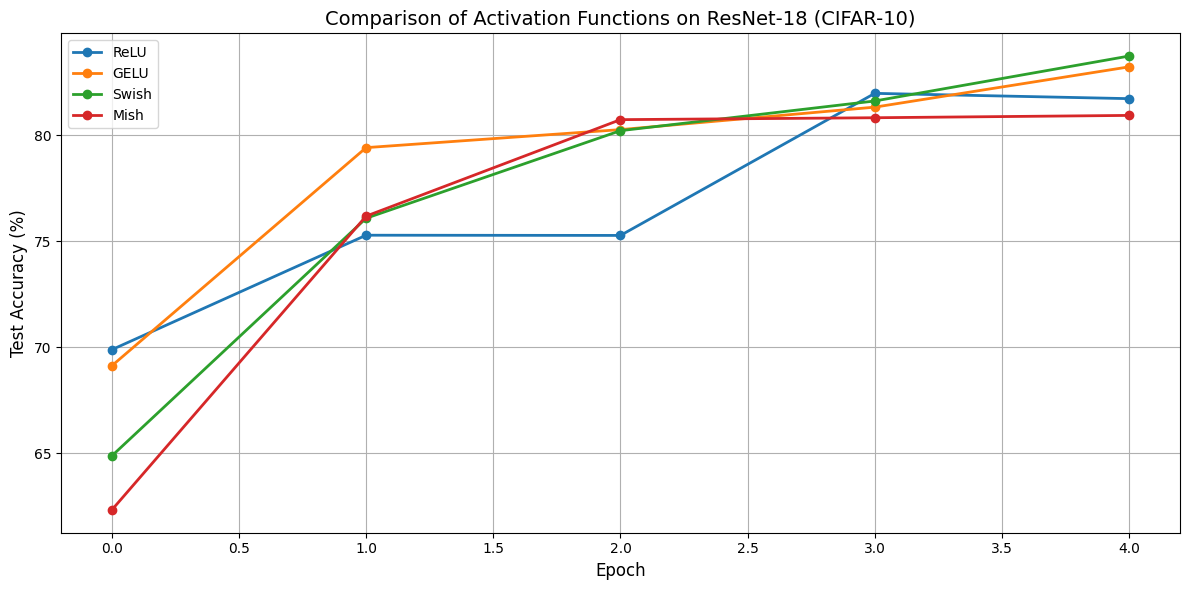

In [ ]:
# FINAL ACCURACY COMPARISON GRAPH

plt.figure(figsize=(12,6))

for name in activations.keys():
    plt.plot(resnet_results[name], marker='o', linewidth=2, label=f"{name}")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Comparison of Activation Functions on ResNet-18 (CIFAR-10)", fontsize=14)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ResNet ReLU


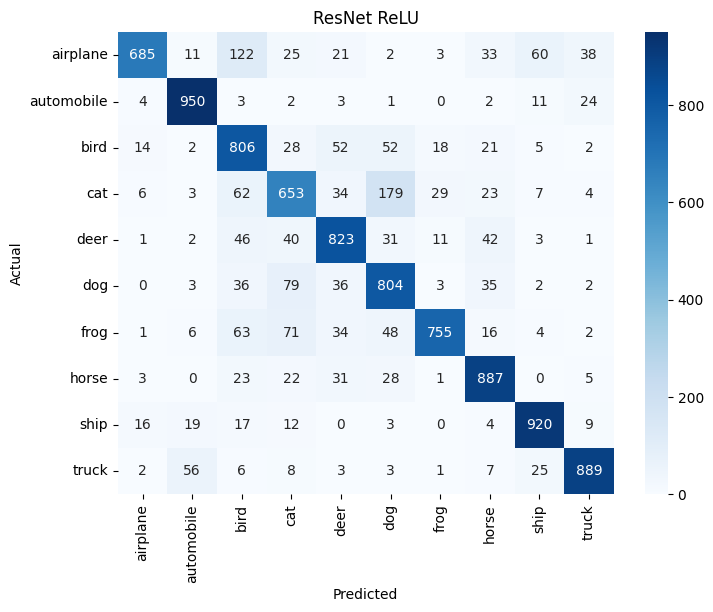

Accuracy: 0.8172

ResNet GELU


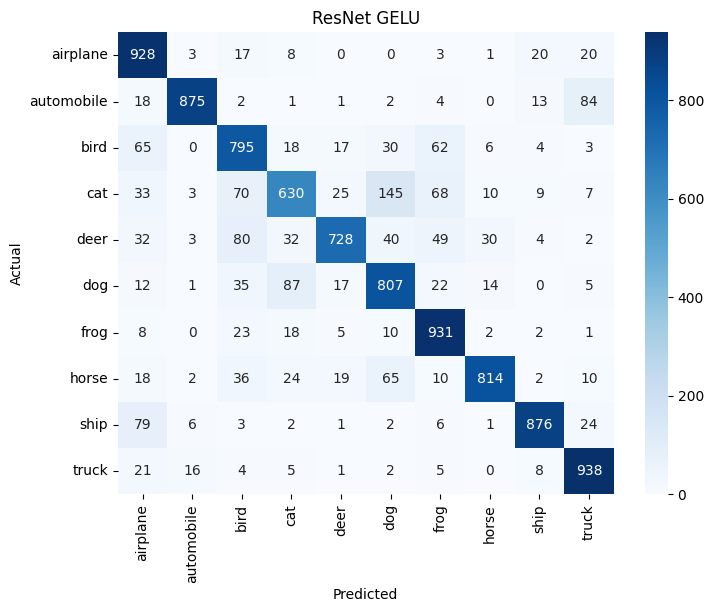

Accuracy: 0.8322

ResNet Swish


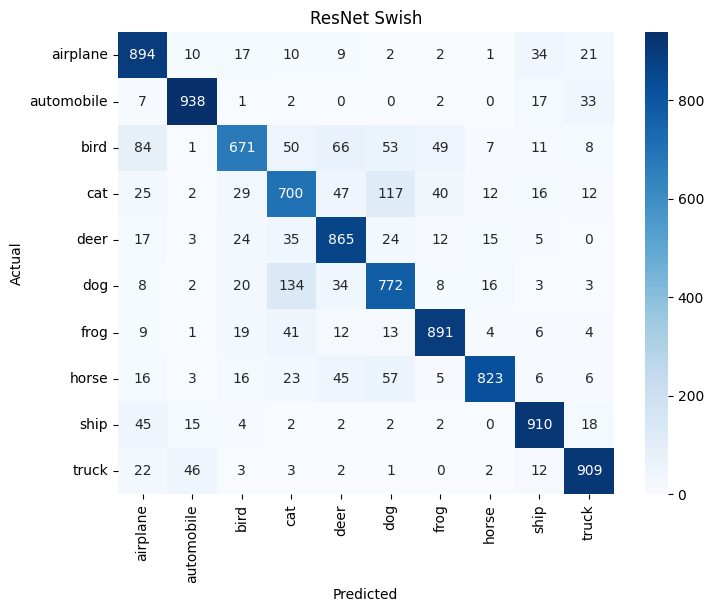

Accuracy: 0.8373

ResNet Mish


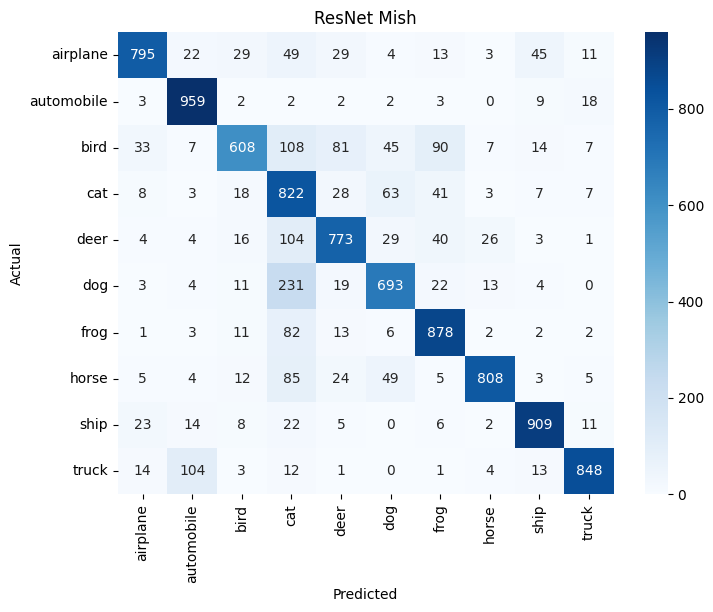

Accuracy: 0.8093


In [ ]:
# CONFUSION MATRICES

for name, model in resnet_models.items():   #Creates a confusion matrix for that model using actual labels and models predictions
    print(f"\nResNet {name}")
    y_true, y_pred = get_predictions(model)
    plot_confusion(y_true, y_pred, f"ResNet {name}")

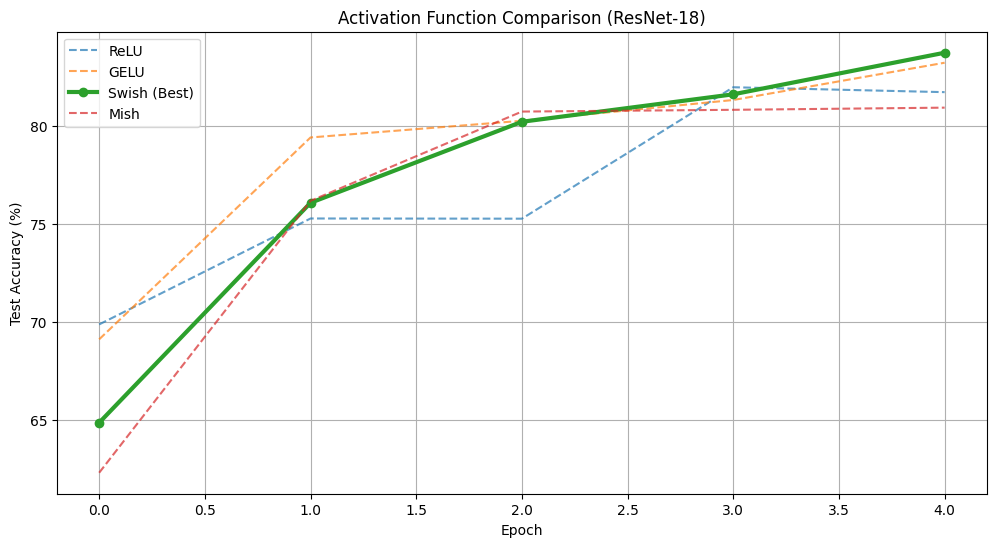


Best Activation Function: Swish


In [ ]:
# Find best activation
best_activation = max(resnet_results, key=lambda x: resnet_results[x][-1])    #Select the activation function with the highest final test accuracy

plt.figure(figsize=(12,6))

for name in activations.keys():
    if name == best_activation:
        plt.plot(resnet_results[name], marker='o', linewidth=3, label=f"{name} (Best)")
    else:
        plt.plot(resnet_results[name], linestyle='--', alpha=0.7, label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Activation Function Comparison (ResNet-18)")

plt.legend()
plt.grid(True)
plt.show()

print(f"\nBest Activation Function: {best_activation}")